<a href="https://colab.research.google.com/github/sashank1326/ML_Practice/blob/main/CNN(LeNet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LeNet**

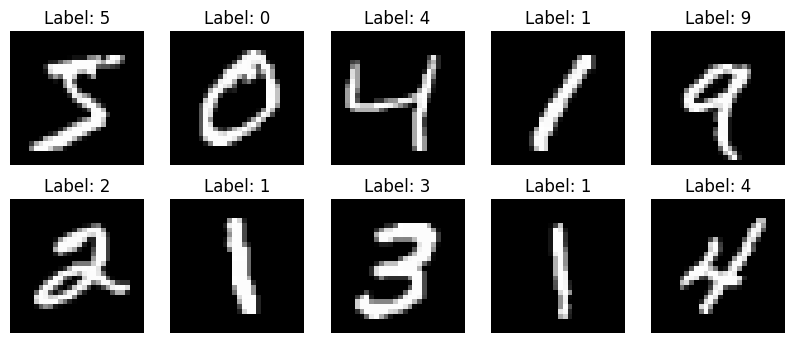

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8608 - loss: 0.4692 - val_accuracy: 0.9356 - val_loss: 0.2038
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9341 - loss: 0.2165 - val_accuracy: 0.9612 - val_loss: 0.1289
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9541 - loss: 0.1479 - val_accuracy: 0.9702 - val_loss: 0.0995
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9641 - loss: 0.1166 - val_accuracy: 0.9755 - val_loss: 0.0787
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9706 - loss: 0.0941 - val_accuracy: 0.9794 - val_loss: 0.0699
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9736 - loss: 0.0806 - val_accuracy: 0.9799 - val_loss: 0.0686
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9777 - loss: 0.0712 - val_accuracy: 0.9829 - val_loss: 0.0599
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9802 - loss: 0.0628 - 

In [ ]:
#Import Necessary Libraries
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt
from keras.layers import Dropout


#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

#Visualize The Training Data

plt.figure(figsize=(10, 4))  # Set The size Of The Figure
for i in range(10):
    plt.subplot(2, 5, i + 1)  # Make subplots for 10 images
    plt.imshow(x_train[i], cmap='gray')  # Display The grayscale images
    plt.title(f"Label: {y_train[i]}")  # Add labels
    plt.axis('off')  # Axis Labels Turned Off
plt.show()  # Displaying the plot


#Data Processing
#Split The Data Into Training And Validation Set
#Here, we will split the data into the training and validation set.

# Consider The First 50000 samples As The Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

# Conside The Last 10000 Samples AS The Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]


#Normalize the Data
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

#Reshape data
#Change the shape of the arrays to include the color channel of the images. Since the images are grayscale, the color channel is 1.


x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


#One Hot Encoding
#Perform one-hot encoding to convert categorical data into binary vectors.
#Each element in the binary vector corresponds to a class, and only one element is 1, while the rest are 0.
#For example, if there are 10 classes and the label is 3, the one-hot encoded vector would be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)



#Build LeNet5 Model
#Create An Instance of Sequential Class.
LeNet5_Model=Sequential()

# Add First Convolutional Layer
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

# Add First Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Add Second Convolutional Layer
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

# Add Second Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Flatten The Layer
LeNet5_Model.add(Flatten())
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dropout(0.2))

LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dropout(0.2))

LeNet5_Model.add(Dense(10, activation='softmax'))

#Compile The Model
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


#Check Model Summary
LeNet5_Model.summary()


#Train The Model
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))


#Evaluate The Model Performance On The Test Dataset
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)


# **AlexNet**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 28, 28, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,210,250 (23.69 MB)

 Trainable params: 6,210,250 (23.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.9114 - loss: 0.2684 - val_accuracy: 0.9795 - val_loss: 0.0777
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9836 - loss: 0.0576 - val_accuracy: 0.9865 - val_loss: 0.0487
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9884 - loss: 0.0400 - val_accuracy: 0.9908 - val_loss: 0.0311
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9915 - loss: 0.0314 - val_accuracy: 0.9915 - val_loss: 0.0370
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9920 - loss: 0.0283 - val_accuracy: 0.9917 - val_loss: 0.0324
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9937 - loss: 0.0227 - val_accuracy: 0.9904 - val_loss: 0.0493
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9938 - loss: 0.0230 - val_accuracy: 0.9916 - val_loss: 0.0427
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9944 - loss: 0.0203 - 

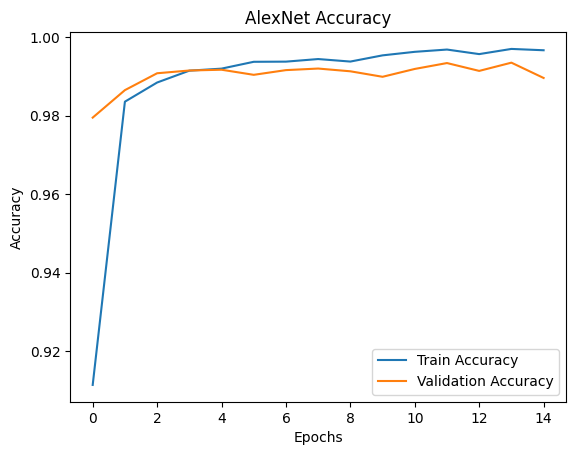

In [2]:
# ================== IMPORT LIBRARIES ==================
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# ================== LOAD DATA ==================
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# ================== PREPROCESSING ==================

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Split
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# ================== BUILD ALEXNET ==================

AlexNet_Model = Sequential()

# -------- Layer 1 --------
AlexNet_Model.add(Conv2D(96, (3,3), strides=1, padding='same',
                         activation='relu', input_shape=(28,28,1)))
AlexNet_Model.add(MaxPooling2D(pool_size=(2,2), strides=2))

# -------- Layer 2 --------
AlexNet_Model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
AlexNet_Model.add(MaxPooling2D(pool_size=(2,2), strides=2))

# -------- Layer 3 --------
AlexNet_Model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

# -------- Layer 4 --------
AlexNet_Model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

# -------- Layer 5 --------
AlexNet_Model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
AlexNet_Model.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten
AlexNet_Model.add(Flatten())

# Fully Connected Layers
AlexNet_Model.add(Dense(1024, activation='relu'))
AlexNet_Model.add(Dropout(0.5))

AlexNet_Model.add(Dense(512, activation='relu'))
AlexNet_Model.add(Dropout(0.5))

# Output
AlexNet_Model.add(Dense(10, activation='softmax'))

# ================== COMPILE ==================
AlexNet_Model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================== SUMMARY ==================
AlexNet_Model.summary()

# ================== TRAIN ==================
history = AlexNet_Model.fit(
    x_train_main, y_train_main,
    epochs=15,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# ================== EVALUATE ==================
test_loss, test_acc = AlexNet_Model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ================== PLOT ==================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("AlexNet Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# **ZFNet**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


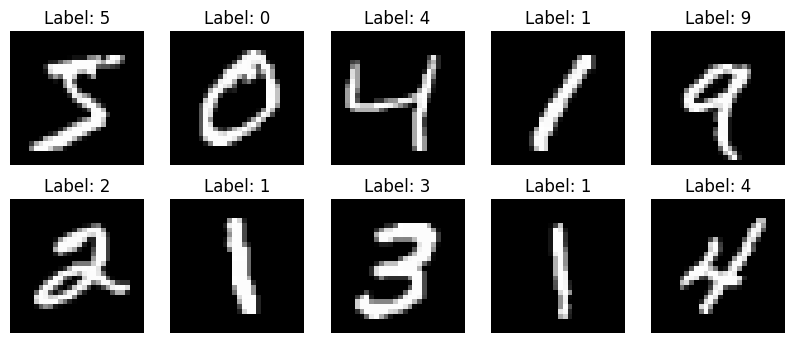

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 96)     │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,982,538 (15.19 MB)

 Trainable params: 3,982,538 (15.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.8503 - loss: 0.4363 - val_accuracy: 0.9842 - val_loss: 0.0629
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9828 - loss: 0.0689 - val_accuracy: 0.9833 - val_loss: 0.0699
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9882 - loss: 0.0491 - val_accuracy: 0.9858 - val_loss: 0.0560
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9906 - loss: 0.0397 - val_accuracy: 0.9881 - val_loss: 0.0501
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9924 - loss: 0.0317 - val_accuracy: 0.9894 - val_loss: 0.0457
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9932 - loss: 0.0286 - val_accuracy: 0.9876 - val_loss: 0.0630
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9940 - loss: 0.0247 - val_accuracy: 0.9880 - val_loss: 0.0639
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9947 - loss: 0.0227 - val_acc

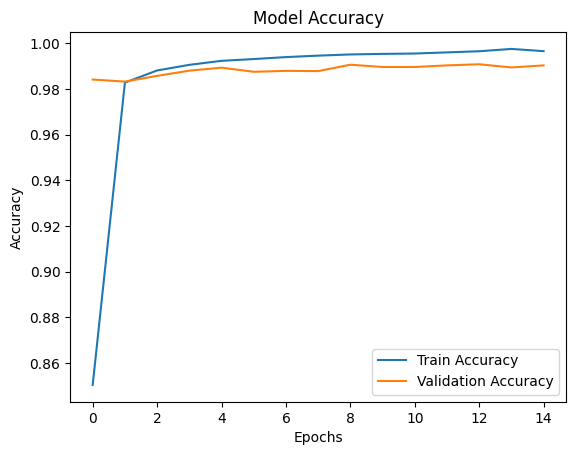

In [ ]:
# ================== IMPORT LIBRARIES ==================
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# ================== LOAD DATA ==================
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# ================== VISUALIZE ==================
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# ================== PREPROCESSING ==================

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Train / Validation split
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# ================== BUILD ZF-NET MODEL ==================

ZF_Model = Sequential()

# 1st Conv Layer
ZF_Model.add(Conv2D(96, (7,7), strides=2, padding='same', activation='relu', input_shape=(28,28,1)))
ZF_Model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Conv Layer
ZF_Model.add(Conv2D(256, (5,5), strides=1, padding='same', activation='relu'))
ZF_Model.add(MaxPooling2D(pool_size=(2,2)))

# 3rd Conv Layer
ZF_Model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

# 4th Conv Layer
ZF_Model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

# 5th Conv Layer
ZF_Model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
ZF_Model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
ZF_Model.add(Flatten())

# Fully Connected Layers (reduced size for MNIST)
ZF_Model.add(Dense(512, activation='relu'))
ZF_Model.add(Dropout(0.5))

ZF_Model.add(Dense(256, activation='relu'))
ZF_Model.add(Dropout(0.5))

# Output Layer
ZF_Model.add(Dense(10, activation='softmax'))

# ================== COMPILE ==================
ZF_Model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================== SUMMARY ==================
ZF_Model.summary()

# ================== TRAIN ==================
history = ZF_Model.fit(
    x_train_main, y_train_main,
    epochs=15,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# ================== EVALUATE ==================
test_loss, test_acc = ZF_Model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ================== PLOT ACCURACY ==================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# **VGGNet**

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 615,786 (2.35 MB)

 Trainable params: 615,786 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.8859 - loss: 0.3560 - val_accuracy: 0.9848 - val_loss: 0.0557
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9768 - loss: 0.0899 - val_accuracy: 0.9882 - val_loss: 0.0455
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9845 - loss: 0.0609 - val_accuracy: 0.9889 - val_loss: 0.0398
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9872 - loss: 0.0475 - val_accuracy: 0.9907 - val_loss: 0.0331
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9900 - loss: 0.0384 - val_accuracy: 0.9915 - val_loss: 0.0321
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9913 - loss: 0.0323 - val_accuracy: 0.9902 - val_loss: 0.0343
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9934 - loss: 0.0260 - val_accuracy: 0.9925 - val_loss: 0.0316
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9943 - loss: 0.0216 - val_acc

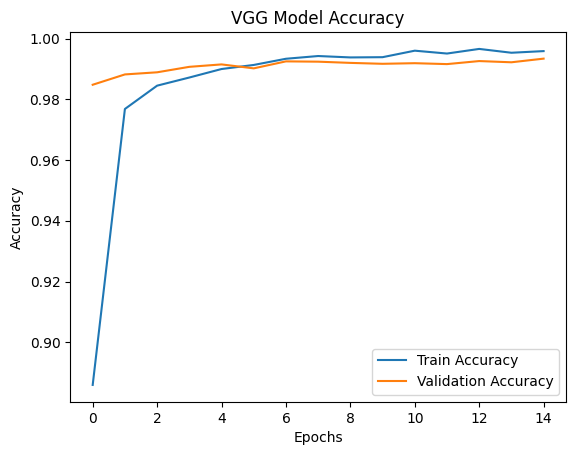

In [ ]:
# ================== IMPORT LIBRARIES ==================
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# ================== LOAD DATA ==================
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# ================== PREPROCESSING ==================

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Train / Validation split
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# ================== BUILD VGG MODEL ==================

VGG_Model = Sequential()

# -------- Block 1 --------
VGG_Model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
VGG_Model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
VGG_Model.add(MaxPooling2D((2,2)))

# -------- Block 2 --------
VGG_Model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
VGG_Model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
VGG_Model.add(MaxPooling2D((2,2)))

# -------- Block 3 --------
VGG_Model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
VGG_Model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
VGG_Model.add(MaxPooling2D((2,2)))

# Flatten
VGG_Model.add(Flatten())

# Fully Connected Layers
VGG_Model.add(Dense(256, activation='relu'))
VGG_Model.add(Dropout(0.5))

VGG_Model.add(Dense(128, activation='relu'))
VGG_Model.add(Dropout(0.5))

# Output Layer
VGG_Model.add(Dense(10, activation='softmax'))

# ================== COMPILE ==================
VGG_Model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================== SUMMARY ==================
VGG_Model.summary()

# ================== TRAIN ==================
history = VGG_Model.fit(
    x_train_main, y_train_main,
    epochs=15,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# ================== EVALUATE ==================
test_loss, test_acc = VGG_Model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ================== PLOT ==================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("VGG Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# **GoogleNet**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │      2,080 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │      1,040 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ max_pooling2d[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │      2,080 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     18,496 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │     12,832 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │      2,080 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 160)              │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │     10,304 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │      5,152 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 14, 14,    │     10,304 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     73,856 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                 

 Total params: 1,050,042 (4.01 MB)

 Trainable params: 1,050,042 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 68ms/step - accuracy: 0.8784 - loss: 0.3631 - val_accuracy: 0.9772 - val_loss: 0.0682
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9778 - loss: 0.0729 - val_accuracy: 0.9865 - val_loss: 0.0462
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9844 - loss: 0.0522 - val_accuracy: 0.9914 - val_loss: 0.0280
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.9890 - loss: 0.0380 - val_accuracy: 0.9895 - val_loss: 0.0344
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9901 - loss: 0.0338 - val_accuracy: 0.9889 - val_loss: 0.0477
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9912 - loss: 0.0300 - val_accuracy: 0.9914 - val_loss: 0.0287
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9930 - loss: 0.0241 - val_accuracy: 0.9873 - val_loss: 0.0451
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9932 - loss: 0.0222 - 

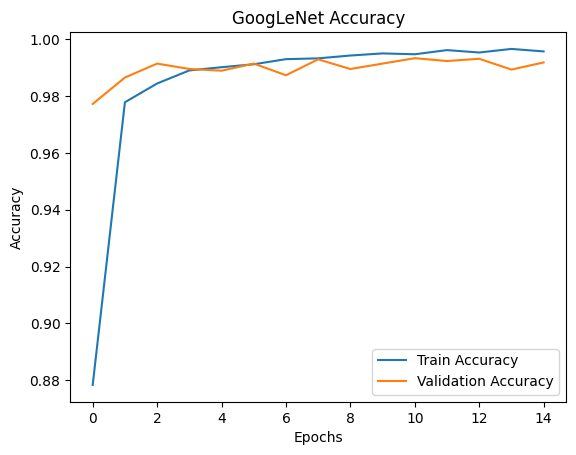

In [1]:
# ================== IMPORT LIBRARIES ==================
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.layers import Input, concatenate, AveragePooling2D
import matplotlib.pyplot as plt

# ================== LOAD DATA ==================
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# ================== PREPROCESSING ==================

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Split
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# ================== INCEPTION MODULE ==================
def inception_module(x, filters):

    f1, f3r, f3, f5r, f5, pool = filters

    # 1x1
    conv1 = Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    # 1x1 -> 3x3
    conv3 = Conv2D(f3r, (1,1), padding='same', activation='relu')(x)
    conv3 = Conv2D(f3, (3,3), padding='same', activation='relu')(conv3)

    # 1x1 -> 5x5
    conv5 = Conv2D(f5r, (1,1), padding='same', activation='relu')(x)
    conv5 = Conv2D(f5, (5,5), padding='same', activation='relu')(conv5)

    # Pool -> 1x1
    pool_layer = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    pool_layer = Conv2D(pool, (1,1), padding='same', activation='relu')(pool_layer)

    # Concatenate
    output = concatenate([conv1, conv3, conv5, pool_layer], axis=-1)

    return output

# ================== BUILD GOOGLENET ==================

input_layer = Input(shape=(28,28,1))

# Initial Conv
x = Conv2D(64, (3,3), padding='same', activation='relu')(input_layer)
x = MaxPooling2D((2,2))(x)

# Inception Blocks
x = inception_module(x, [32, 32, 64, 16, 32, 32])
x = inception_module(x, [64, 64, 128, 32, 64, 64])

x = MaxPooling2D((2,2))(x)

x = inception_module(x, [128, 64, 128, 32, 64, 64])
x = inception_module(x, [128, 64, 128, 32, 64, 64])

# Global Average Pooling (simplified)
x = AveragePooling2D((3,3))(x)

x = Flatten()(x)

# Fully Connected
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output_layer = Dense(10, activation='softmax')(x)

# Model
model = Model(inputs=input_layer, outputs=output_layer)

# ================== COMPILE ==================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================== SUMMARY ==================
model.summary()

# ================== TRAIN ==================
history = model.fit(
    x_train_main, y_train_main,
    epochs=15,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# ================== EVALUATE ==================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ================== PLOT ==================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("GoogLeNet Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()